# Physics 311 — Setup Verification Notebook

**Module 0, Item 0.5 &nbsp;|&nbsp; 10 points**

Welcome! This notebook confirms that your development environment is ready for Physics 311. It checks that Python and all required libraries are installed and working, and it runs your **first physics simulation** — a ball in free fall, solved with the Euler method.

## How to use this notebook

1. **Fill in your name and the date** in the cell below.
2. Run every cell **in order**, from top to bottom. (Click a cell and press **Shift + Enter**, or use **Run → Run All Cells**.)
3. Watch for a ✅ or ❌ after each check.
4. When you reach the end, you should see a plot of a falling ball and a big **ALL CHECKS PASSED** message.
5. Before submitting: go to **Kernel → Restart Kernel and Run All Cells** to make sure everything runs cleanly from a fresh start.

> **If any check fails:** don't panic. Copy the exact error message and post it in the **Help Desk — Python** discussion along with (1) your operating system and (2) what you've tried. Debugging together is part of how this course works.

## What to submit

- The **completed notebook** (`verify_setup.ipynb`) with all cells run and outputs visible, uploaded to Canvas.
- Also commit and push it to your `phys311` repo under `checkpoints/` (optional but good practice).

---
## Step 0 — Your Information

Edit the strings below, then run the cell.

In [8]:
# ✏️ EDIT THESE TWO LINES
student_name = "Marianne Breinig"
todays_date  = "2026-08-15"

print(f"Setup verification for: {student_name}")
print(f"Date: {todays_date}")

Setup verification for: Marianne Breinig
Date: 2026-08-15


---
## Step 1 — Check Your Python Version

This course requires **Python 3.10 or newer**. The cell below checks your version.

In [9]:
import sys

major, minor = sys.version_info.major, sys.version_info.minor
print(f"You are running Python {major}.{minor} ({sys.version.split()[0]})")

if (major, minor) >= (3, 10):
    print("✅ Python version OK (3.10+)")
else:
    print("❌ Python is too old. This course needs Python 3.10 or newer.")
    print("   Revisit Step 2 of the Technology Setup Guide (install Miniconda).")

You are running Python 3.12 (3.12.13)
✅ Python version OK (3.10+)


---
## Step 2 — Check Required Libraries

This course uses four core scientific libraries:

| Library | What it does |
|---|---|
| **NumPy** | Fast numerical arrays and math |
| **Matplotlib** | Plotting and visualization |
| **SciPy** | Advanced scientific algorithms |
| **Jupyter** | The notebook environment you're using right now |

The cell below tries to import each one and reports its version.

In [10]:
import importlib

required = ["numpy", "matplotlib", "scipy"]

all_ok = True
for name in required:
    try:
        mod = importlib.import_module(name)
        version = getattr(mod, "__version__", "unknown")
        print(f"✅ {name:<12} version {version}")
    except ImportError:
        all_ok = False
        print(f"❌ {name:<12} NOT installed")
        print(f"     Fix: run  conda install {name}  (or  pip install {name})")

try:
    import notebook  # noqa: F401
    print(f"✅ {'jupyter':<12} available (you're running in it!)")
except ImportError:
    try:
        import jupyter_core  # noqa: F401
        print(f"✅ {'jupyter':<12} available")
    except ImportError:
        print("⚠️  jupyter package not detected, but this notebook is running, so you're fine.")

if all_ok:
    print("\n✅ All required libraries are installed.")
else:
    print("\n❌ Some libraries are missing — see the fixes above, then re-run this cell.")

✅ numpy        version 2.5.1
✅ matplotlib   version 3.11.0
✅ scipy        version 1.18.0
✅ jupyter      available (you're running in it!)

✅ All required libraries are installed.


---
## Step 3 — Quick NumPy Test

A tiny sanity check that NumPy can create arrays and do math.

In [11]:
import numpy as np

a = np.array([1.0, 2.0, 3.0, 4.0])
b = np.linspace(0, 1, 4)

print("Array a:       ", a)
print("Array b:       ", b)
print("a + b:         ", a + b)
print("Mean of a:     ", a.mean())
print("sqrt of a:     ", np.sqrt(a))

if np.isclose(a.mean(), 2.5):
    print("\n✅ NumPy is working correctly.")
else:
    print("\n❌ Unexpected result — please post in the Help Desk.")

Array a:        [1. 2. 3. 4.]
Array b:        [0.         0.33333333 0.66666667 1.        ]
a + b:          [1.         2.33333333 3.66666667 5.        ]
Mean of a:      2.5
sqrt of a:      [1.         1.41421356 1.73205081 2.        ]

✅ NumPy is working correctly.


---
## Step 4 — Quick Matplotlib Test

This confirms plots render **inside the notebook**. You should see a simple sine curve appear below the cell.

C:\Users\mbrei\AppData\Local\Temp\ipykernel_15324\3854652017.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


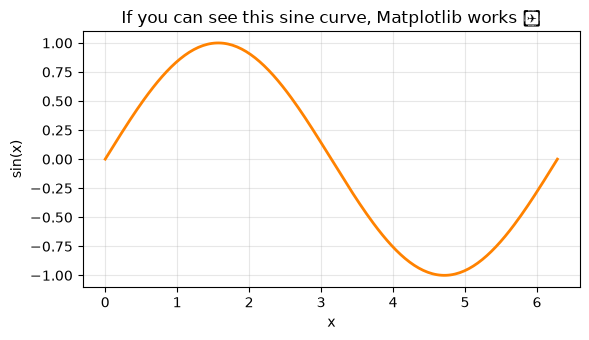

✅ If a smooth orange sine curve appeared above, Matplotlib is working.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

plt.figure(figsize=(6, 3.5))
plt.plot(x, y, color="#ff8200", linewidth=2)
plt.title("If you can see this sine curve, Matplotlib works ✅")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ If a smooth orange sine curve appeared above, Matplotlib is working.")

---
## Step 5 — Your First Physics Simulation 🎉

Here's a preview of what this whole course is about. Below is a complete simulation of a **ball dropped from rest** at a height of 100 m, computed with the **Euler method** — the same technique you'll use in Lab 1.

The idea in three lines of physics:
- Acceleration is constant: $$a = -g$$
- Update velocity each step: $$v_{new} = v + a\,\Delta t$$
- Update position each step: $$y_{new} = y + v\,\Delta t$$

Repeat that thousands of times and you've simulated free fall. Run the cell and watch it work.

Ball dropped from 100 m
Time to land (simulation): 4.520 s
Time to land (exact):      4.515 s
Difference:                0.005 s


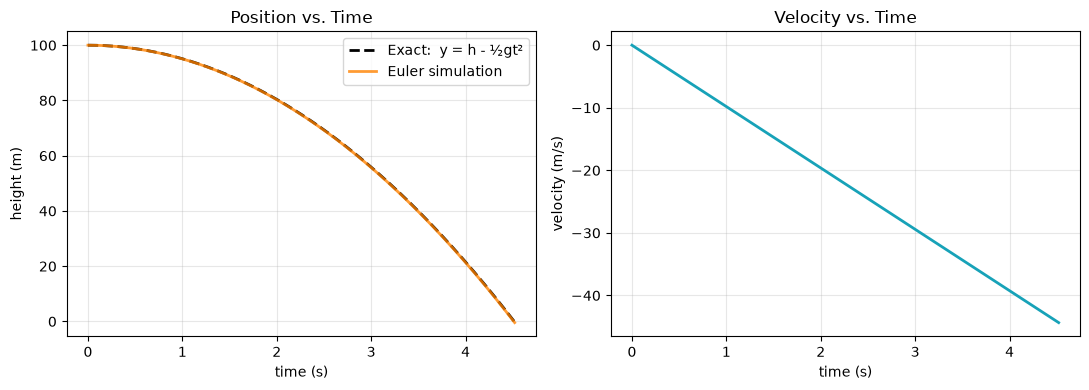


✅ Your first simulation matches theory. Nice work!


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
g  = 9.81      # gravitational acceleration (m/s^2)
h0 = 100.0     # initial height (m)
dt = 0.01      # time step (s)

# --- Initial state ---
y  = h0        # position
v  = 0.0       # velocity (released from rest)
t  = 0.0

# --- Storage for plotting ---
ts, ys, vs = [t], [y], [v]

# --- Euler integration loop: run until the ball hits the ground ---
while y > 0:
    a = -g                 # Newton's 2nd law: only gravity acts
    v = v + a * dt         # update velocity
    y = y + v * dt         # update position
    t = t + dt
    ts.append(t); ys.append(y); vs.append(v)

ts, ys, vs = np.array(ts), np.array(ys), np.array(vs)

# --- Compare to the exact analytical solution ---
t_exact = np.linspace(0, ts[-1], 200)
y_exact = h0 - 0.5 * g * t_exact**2

# --- Report results ---
t_land_numeric = ts[-1]
t_land_exact   = np.sqrt(2 * h0 / g)
print(f"Ball dropped from {h0:.0f} m")
print(f"Time to land (simulation): {t_land_numeric:.3f} s")
print(f"Time to land (exact):      {t_land_exact:.3f} s")
print(f"Difference:                {abs(t_land_numeric - t_land_exact):.3f} s")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(t_exact, y_exact, 'k--', label="Exact:  y = h - ½gt²", linewidth=2)
ax1.plot(ts, ys, color="#ff8200", label="Euler simulation", linewidth=2, alpha=0.8)
ax1.set_xlabel("time (s)"); ax1.set_ylabel("height (m)")
ax1.set_title("Position vs. Time")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ts, vs, color="#17a2b8", linewidth=2)
ax2.set_xlabel("time (s)"); ax2.set_ylabel("velocity (m/s)")
ax2.set_title("Velocity vs. Time")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if abs(t_land_numeric - t_land_exact) < 0.05:
    print("\n✅ Your first simulation matches theory. Nice work!")
else:
    print("\n⚠️ Simulation ran, but drifted from theory more than expected (try a smaller dt).")

---
## Step 6 — Final Summary

Run the cell below to confirm everything is in order.

In [14]:
import sys

checks = []
checks.append(("Python 3.10+", sys.version_info[:2] >= (3, 10)))
for name in ["numpy", "matplotlib", "scipy"]:
    try:
        __import__(name)
        checks.append((name, True))
    except ImportError:
        checks.append((name, False))

print("=" * 44)
print("  PHYSICS 311 — SETUP VERIFICATION SUMMARY")
print("=" * 44)
for label, ok in checks:
    print(f"  {'✅' if ok else '❌'}  {label}")
print("=" * 44)

if all(ok for _, ok in checks):
    print()
    print("   🎉  ALL CHECKS PASSED  🎉")
    print()
    print("   Your environment is ready for Physics 311.")
    first = student_name.split()[0] if student_name != 'Your Name Here' else 'student'
    print(f"   Great work, {first}!")
    print()
    print("   Next steps:")
    print("     1. Kernel → Restart Kernel and Run All Cells")
    print("     2. Save the notebook (Ctrl/Cmd + S)")
    print("     3. Upload verify_setup.ipynb to Canvas (Item 0.5)")
else:
    print()
    print("   ❌ Some checks failed. Scroll up to find the ❌ marks,")
    print("      follow the suggested fixes, then re-run all cells.")
    print("      Still stuck? Post in the Help Desk — Python discussion.")

  PHYSICS 311 — SETUP VERIFICATION SUMMARY
  ✅  Python 3.10+
  ✅  numpy
  ✅  matplotlib
  ✅  scipy

   🎉  ALL CHECKS PASSED  🎉

   Your environment is ready for Physics 311.
   Great work, Marianne!

   Next steps:
     1. Kernel → Restart Kernel and Run All Cells
     2. Save the notebook (Ctrl/Cmd + S)
     3. Upload verify_setup.ipynb to Canvas (Item 0.5)


---

### ✅ Before you submit — final checklist

- [ ] I edited **Step 0** with my name and today's date
- [ ] I ran **Kernel → Restart Kernel and Run All Cells** with no errors
- [ ] I saw the **sine curve** (Step 4) and the **free-fall plots** (Step 5)
- [ ] I saw **ALL CHECKS PASSED** at the bottom
- [ ] I saved the notebook and uploaded `verify_setup.ipynb` to Canvas

*Welcome to Physics 311 — you just ran your first numerical mechanics simulation.* 🚀